In [1]:
import shlex
import subprocess
from pathlib import Path
from typing import Callable
from dotenv import load_dotenv
from skills_ref import to_prompt
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.messages import SystemMessage
from langchain_core.messages import HumanMessage
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

load_dotenv()

True

In [2]:
# 自定义可靠的 Shell 工具
@tool
def run_shell(command: str) -> str:
    """执行 shell 命令。command 参数是一个字符串，可以包含空格和特殊字符。"""
    import subprocess
    try:
        result = subprocess.run(
            command,
            shell=True,
            capture_output=True,
            text=True,
            timeout=30
        )
        output = result.stdout if result.returncode == 0 else result.stderr
        return output if output else f"命令执行完成 (返回码: {result.returncode})"
    except Exception as e:
        return f"执行错误: {str(e)}"



In [8]:
@tool
def get_skill_instruction(skill_name: str) -> str:
    """获取指定技能的详细指令及脚本清单。"""
    base = Path("./skills") / skill_name
    file = base / "SKILL.md"

    if not file.exists():
        return f"错误：找不到技能 {skill_name}"

    content = file.read_text(encoding="utf-8")
    body = content.split("---")[-1].strip()

    scripts = [f.name for f in (base / "scripts").glob("*") if f.is_file()]
    script_info = f"\n\n📂 **可用脚本**: {', '.join(scripts)}" if scripts else "\n\n📂 **可用脚本**: 无"

    return (
        f"# {skill_name} 详情\n"
        f"📍 **技能路径**: `{base}`\n\n"
        f"{body}"
        f"{script_info}"
    )


@wrap_model_call
def add_context(
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    skills_root = Path("./skills")
    skill_paths = [p for p in skills_root.iterdir() if p.is_dir() and (p / "SKILL.md").exists()]
    skills_catalog = to_prompt(skill_paths)
    system_prompt = f"""
# Role
你是一个功能强大的通用人工智能助手。为了更高效、精准地完成复杂任务，你拥有访问“专用技能库”的权限。

# 技能目录 (Skill Catalog)
以下是你当前可以调用的扩展技能列表。每个技能包含名称和核心功能简述：

{skills_catalog}

# 核心操作逻辑 (Operating Logic)
当你处理用户请求时，请遵循以下决策流程：

1. **意图匹配**：判断用户需求是否落在上述 [技能目录] 的覆盖范围内。
2. **按需检索**：如果你决定使用某个技能，**严禁凭经验盲目猜测其操作细节**。你必须立即调用工具 `get_skill_instruction(skill_name)` 来获取该技能的“详细操作手册”。
3. **知识利用**：
    - 阅读手册中提供的执行步骤、参数规范及约束条件。
    - 如果手册中提到需要运行特定的脚本（通常位于 `skills/技能名/scripts/`），请严格按照说明执行对应的命令行操作。
4. **组合执行**：你可以根据任务复杂度，依次检索并利用多个技能来构建完整的解决方案。

# 行为约束
- **先读后做**：在未获取详细指令前，不得尝试调用该技能目录下的任何脚本或文件。
- **路径感知**：使用相对于当前工作目录的完整路径。
- **结果导向**：利用技能解决问题后，简洁反馈结果。
"""
    system_message = SystemMessage(content=system_prompt)
    return handler(request.override(system_message=system_message))


agent = create_agent(ChatOpenAI(model="qwen3.5-plus"), tools=[get_skill_instruction, run_shell],
                     middleware=[add_context])

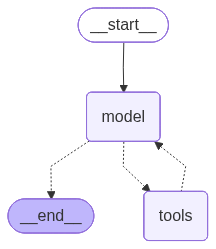

In [9]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

In [10]:
user_query = "帮我创建一个可以提取图片经纬度信息的工具，工具需要有脚本哦。"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 50}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

帮我创建一个可以提取图片经纬度信息的工具，工具需要有脚本哦。
================================== Ai Message ==================================
Tool Calls:
  get_skill_instruction (call_e8f9542fa3454124b7517c27)
 Call ID: call_e8f9542fa3454124b7517c27
  Args:
    skill_name: skill-creator
================================= Tool Message =================================
Name: get_skill_instruction

# skill-creator 详情
📍 **技能路径**: `skills/skill-creator`

` 开头，包含 name 和 description

## 失败排查

如果看到 `SKILL.md must start with YAML frontmatter` 错误，说明 frontmatter 缺失！

📂 **可用脚本**: 无
================================== Ai Message ==================================
Tool Calls:
  run_shell (call_9e65c4ab4a134ffba3a2442f)
 Call ID: call_9e65c4ab4a134ffba3a2442f
  Args:
    command: mkdir -p skills/skill-extract-gps/scripts
================================= Tool Message =================================
Name: run_shell

命令执行完成 (返回码: 0)
==================

In [11]:
user_query = "帮我看看下载文件夹下面，IMG_4113.HEIC照片的经纬度信息"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in agent.stream(inputs, config={"recursion_limit": 50}, stream_mode="values"):
    output["messages"][-1].pretty_print()

================================ Human Message =================================

帮我看看下载文件夹下面，IMG_4113.HEIC照片的经纬度信息
================================== Ai Message ==================================
Tool Calls:
  get_skill_instruction (call_8d680632081c4eef86e37c88)
 Call ID: call_8d680632081c4eef86e37c88
  Args:
    skill_name: skill-extract-gps
================================= Tool Message =================================
Name: get_skill_instruction

# skill-extract-gps 详情
📍 **技能路径**: `skills/skill-extract-gps`

# skill-extract-gps

## 功能描述
该技能可以从包含 EXIF 信息的图片中提取 GPS 经纬度坐标。

## 使用脚本
执行以下命令来提取图片的 GPS 信息：

```bash
python3 skills/skill-extract-gps/scripts/extract_gps.py <图片路径>
```

## 依赖
需要安装 Pillow 库：
```bash
pip install Pillow
```

📂 **可用脚本**: extract_gps.py
================================== Ai Message ==================================
Tool Calls:
  run_shell (call_5e26b81bf8fd42099bcb652a)
 Call ID: call_5e26b81bf8fd42099bcb652a
  Args:
    command: python3 skills/skill-extract-gps